# COMO FLUTUAÇÕES NO PREÇO DO PETRÓLEO INTERNACIONAL AFETAM O VALOR DE REVENDA EM COMBUSTÍVEL BRASILEIRO

1.1 DATASETS UTILIZADOS

https://www.gov.br/anp/pt-br/centrais-de-conteudo/dados-abertos/serie-historica-de-precos-de-combustiveis

https://www.kaggle.com/datasets/sc231997/crude-oil-price?resource=download

1.2 DESCRIÇÃO DOS DATASETS:

Data set 1: Preços historicamente registrados semanalmente, agrupados semestralmente disponibilizados pela ANP/SDC (Superintendência de Defesa da Concorrência) no site do gov.br em csv.

Data set 2: Preços de crude oil disponibilizados na pataforma kaggle retirados de  https://tradingeconomics.com/commodity/crude-oil atualizado mensalmente em csv.

1.3 Problemática: Assimetria entre transmissão de preços da gasolina vs petróleo/Quanto tempo leva para as flutuações nos preços afetarem os preços de revenda afetando os brasileiros.

1.4 Perguntas analiticas:  

Existe assimetria na evolução do preço da gasolina brasileira para a evolução do preço bruto do petróleo?

Quanto tempo demora para curvas agudas no valor do petróleo internacional chegarem nas bombas de gasolina brasileiras?

O aumento da cota de etanol na gasolina brasileira foi uma medida eficiente para conter a intensidade da transmissão do repasse das variações do petróleo bruto internacional?

A itensidade da transmissão do repasse da variação de preços do crude oil muda dependendo da intensidade da curva? Ex: Impactos de aumentos repentinos como em guerras vs impactos de aumentos graduais.

talvez: Existe impacto nesse crescimento em anos eleitorais?


#2.0 LIMPEZA DE DADOS

1.1 Primeiro, antes de conferir dados faltantes, ajuda juntar todos os dados de csv da gasolina brasileira

In [2]:
#Importar as bibliotecas e ler o dataset

import pandas as pd
import glob
#files = glob.glob("C:/Users/doend/Desktop/Csv gasolina/*.csv")

#df = pd.concat([pd.read_csv(f, sep= ';', encoding = 'latin1', on_bad_lines = 'skip') for f in files], ignore_index=True)
df = pd.read_csv('gasolina_consolidado.csv')
print(df.head())
#para vermos como esta a formatacao

C:\Users\tomas\AppData\Local\Temp\ipykernel_22064\1855868235.py:8: DtypeWarning: Columns (0,4,13,16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('gasolina_consolidado.csv')


  ï»¿Regiao - Sigla Estado - Sigla  Municipio  \
0                SE             SP  GUARULHOS   
1                SE             SP  GUARULHOS   
2                SE             SP  GUARULHOS   
3                SE             SP   SOROCABA   
4                SE             SP   SOROCABA   

                                             Revenda      CNPJ da Revenda  \
0                           AUTO POSTO SAKAMOTO LTDA   49.051.667/0001-02   
1                           AUTO POSTO SAKAMOTO LTDA   49.051.667/0001-02   
2                           AUTO POSTO SAKAMOTO LTDA   49.051.667/0001-02   
3  COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...   00.003.188/0001-21   
4  COMPETRO COMERCIO E DISTRIBUICAO DE DERIVADOS ...   00.003.188/0001-21   

                Nome da Rua Numero Rua          Complemento          Bairro  \
0  RODOVIA PRESIDENTE DUTRA        S/N  KM 210,5-SENT SP/RJ      BONSUCESSO   
1  RODOVIA PRESIDENTE DUTRA        S/N  KM 210,5-SENT SP/RJ      BONSUCESSO   
2  RO

In [3]:
#df.to_csv(r"C:/Users/doend/Desktop/gasolina_consolidado.csv", index=False)

In [4]:
df.tail()


,ï»¿Regiao - Sigla,Estado - Sigla,Municipio,Revenda,CNPJ da Revenda,Nome da Rua,Numero Rua,Complemento,Bairro,Cep,Produto,Data da Coleta,Valor de Venda,Valor de Compra,Unidade de Medida,Bandeira,Regiao - Sigla
24830626,NE,BA,ALAGOINHAS,2 A COMERCIO DE COMBUSTIVEIS GNV E LUBRIFICANT...,14238511000150,RODOVIA BR 101 KM 116,S/N,SALA 01,CENTRO,48005-440,GNV,31/12/2025,"4,38",NaN,R$ / m3,LARCO,NaN
24830627,NE,PB,BAYEUX,PETROGAS COMERCIO DE COMBUSTIVEIS LTDA,21553439000111,AVENIDA LIBERDADE,3545,ANDAR: 1; ANEXO: A;,SESI,58306-000,GNV,31/12/2025,"4,85",NaN,R$ / m3,ALE,NaN
24830628,NE,BA,ILHEUS,BATISTA COMERCIO DE COMBUSTIVEIS E LUBRIFICANT...,28562491000183,AVENIDA FERROVIARIA,S/N,KM 05 RODOVIA ILHEUS,IGUAPE,45658-340,GNV,31/12/2025,"4,73",NaN,R$ / m3,BRANCA,NaN
24830629,SE,SP,JACAREI,AUTO POSTO BRANCO DE CASTELO LTDA,68912864000385,AVENIDA SIQUEIRA CAMPOS,641,NaN,CENTRO,12308-190,GNV,31/12/2025,"3,99",NaN,R$ / m3,VIBRA,NaN
24830630,S,RS,LAJEADO,SIM REDE DE POSTOS LTDA,7473735018714,RODOVIA ERS-130,2285,KM 72.8,SANTO ANDRE,95912-000,GNV,31/12/2025,"5,65",NaN,R$ / m3,CHARRUA,NaN


In [5]:
print(df.shape)

(24830631, 17)


In [6]:
df.isna().sum()

ï»¿Regiao - Sigla      481970
Estado - Sigla           9114
Municipio                9114
Revenda                  9114
CNPJ da Revenda          9114
Nome da Rua              9114
Numero Rua              21521
Complemento          18243779
Bairro                  84875
Cep                      9114
Produto                  9114
Data da Coleta           9115
Valor de Venda           9115
Valor de Compra      14418646
Unidade de Medida        9115
Bandeira                 9115
Regiao - Sigla       24357775
dtype: int64

In [7]:
#Exluimos algumas colunas
df = df.drop(columns=['Municipio'
                      , 'CNPJ da Revenda', 'Nome da Rua', 'Numero Rua',
                        'Complemento', 'Bairro', 'Bandeira', 'Revenda', 'Estado - Sigla', 'Valor de Compra',
                        'Cep' ])

In [8]:
df = df.drop(columns=['ï»¿Regiao - Sigla'])
df.head()

,Produto,Data da Coleta,Valor de Venda,Unidade de Medida,Regiao - Sigla
0,GASOLINA,11/05/2004,"1,967",R$ / litro,NaN
1,ETANOL,11/05/2004,"0,899",R$ / litro,NaN
2,DIESEL,11/05/2004,"1,299",R$ / litro,NaN
3,GASOLINA,10/05/2004,"1,85",R$ / litro,NaN
4,ETANOL,10/05/2004,"0,78",R$ / litro,NaN


In [9]:
df = df.drop(columns=['Regiao - Sigla'])

In [10]:

df.head()
df['Valor de Venda'] = df['Valor de Venda'].str.replace(',', '.')
df['Valor de Venda'] = df['Valor de Venda'].astype(float)

In [11]:
df = df[df['Produto'].isin(['GASOLINA', 'GASOLINA ADITIVADA'])]

In [12]:
#novo formato do dataset
print(df.shape)

(8891496, 4)


In [13]:
df.to_csv("gasolina_limpa.csv")

In [14]:
#leitura do dataset do petroleo
df_petroleo=pd.read_csv("crude-oil-price.csv")
print(df_petroleo.head())

                        date  price  percentChange  change
0  1983-03-01 00:00:00+00:00  29.27            NaN     NaN
1  1983-04-01 00:00:00+00:00  30.63          4.646    1.36
2  1983-05-01 00:00:00+00:00  30.25         -1.241   -0.38
3  1983-06-01 00:00:00+00:00  31.38          3.736    1.13
4  1983-07-01 00:00:00+00:00  32.00          1.976    0.62


In [15]:
#arrumar as datas 
df_petroleo['date'] = pd.to_datetime(df_petroleo['date'], utc= True).dt.strftime('%d/%m/%Y')
print(df_petroleo['date'])

0      01/03/1983
1      01/04/1983
2      01/05/1983
3      01/06/1983
4      01/07/1983
          ...    
512    01/11/2025
513    01/12/2025
514    01/01/2026
515    01/02/2026
516    01/03/2026
Name: date, Length: 517, dtype: object


In [16]:
print(df_petroleo.shape)

(517, 4)


In [17]:
#encontramos e limpamos alguns dados que estavam faltantes
print(df_petroleo.isna().sum())
df_petroleo['price'] = df_petroleo['price'].astype(float)
df_petroleo = df_petroleo.dropna(subset=['percentChange'])
df_petroleo = df_petroleo.dropna(subset=['change'])




date             0
price            0
percentChange    1
change           1
dtype: int64


In [18]:
print(df_petroleo.shape)
print(df_petroleo.isna().sum())

(516, 4)
date             0
price            0
percentChange    0
change           0
dtype: int64


In [19]:
df_petroleo.to_csv("petroleo_tratado.csv")

In [20]:
df_petroleo.tail()

,date,price,percentChange,change
512,01/11/2025,58.5500,-3.985,-2.4300
513,01/12/2025,57.4200,-1.930,-1.1300
514,01/01/2026,65.2100,13.567,7.7900
515,01/02/2026,67.0200,2.776,1.8100
516,01/03/2026,91.4155,36.400,24.3955


In [21]:
#Tivemos que arrumar o dataset da gasolina pois ele estava em dia,dessa forma transformamos os valores para mensais usando a media do valor no mês
# Arrumamamos a coluna de data para datetime
df['Data da Coleta'] = pd.to_datetime(df['Data da Coleta'], dayfirst=True)

# Agrupamos por Produto, Unidade de Medida, Regiao e mês
df_mensal = (
    df.groupby(
        ['Produto', 'Unidade de Medida',pd.Grouper(key='Data da Coleta', freq='ME')]
    )['Valor de Venda']
    .mean()
    .reset_index()
)

# Renomeamos coluna de data
df_mensal = df_mensal.rename(columns={'Data da Coleta': 'Mes'})

df_mensal.tail()


,Produto,Unidade de Medida,Mes,Valor de Venda
316,GASOLINA ADITIVADA,R$ / litro,2025-08-31,6.398817
317,GASOLINA ADITIVADA,R$ / litro,2025-09-30,6.406521
318,GASOLINA ADITIVADA,R$ / litro,2025-10-31,6.419064
319,GASOLINA ADITIVADA,R$ / litro,2025-11-30,6.389297
320,GASOLINA ADITIVADA,R$ / litro,2025-12-31,6.404587


In [22]:
#So trabalhamoos com a gasolina na ultima analise então renomeamos o coluna do produto
gasolina = df_mensal.loc[df_mensal['Produto'] == 'GASOLINA']
gasolina.head()



,Produto,Unidade de Medida,Mes,Valor de Venda
0,GASOLINA,R$ / litro,2004-05-31,1.982806
1,GASOLINA,R$ / litro,2004-06-30,2.062425
2,GASOLINA,R$ / litro,2004-07-31,2.107405
3,GASOLINA,R$ / litro,2004-08-31,2.127053
4,GASOLINA,R$ / litro,2004-09-30,2.123554


In [23]:
gasolina['Mes'] = pd.to_datetime(gasolina['Mes'])

gasolina['Mes'] = gasolina['Mes'].dt.strftime('%d/%m/%Y')


C:\Users\tomas\AppData\Local\Temp\ipykernel_22064\602958163.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gasolina['Mes'] = pd.to_datetime(gasolina['Mes'])
C:\Users\tomas\AppData\Local\Temp\ipykernel_22064\602958163.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gasolina['Mes'] = gasolina['Mes'].dt.strftime('%d/%m/%Y')


In [24]:
#O dataframe da gasolina ficou dessa maneira para a analise final
gasolina.head()

,Produto,Unidade de Medida,Mes,Valor de Venda
0,GASOLINA,R$ / litro,31/05/2004,1.982806
1,GASOLINA,R$ / litro,30/06/2004,2.062425
2,GASOLINA,R$ / litro,31/07/2004,2.107405
3,GASOLINA,R$ / litro,31/08/2004,2.127053
4,GASOLINA,R$ / litro,30/09/2004,2.123554


In [25]:
df.to_csv('gasolina.csv')

In [26]:
# Iremos usar agora o dataset do petroleo com o valor do cambio,pois antes ele so estava em dolar
petroleo_cambio = pd.read_csv('petroleo_cambio.csv')

petroleo_cambio.head()

,Unnamed: 0.1,Unnamed: 0,date,price,percentChange,change,cambio,preco
0,0,262,2005-01-01,48.20,10.932,4.75,2.1672,104.459044
1,1,263,2005-02-01,51.75,7.365,3.55,2.1672,112.152605
2,2,264,2005-03-01,55.40,7.053,3.65,2.1672,120.062885
3,3,265,2005-04-01,49.72,-10.253,-5.68,2.1672,107.753188
4,4,266,2005-05-01,51.97,4.525,2.25,2.1672,112.629389


In [27]:
#As datas do dataset do petroleo e da gasolina não estavam no mesmo tempo, então fizemos a analise de 2005 até 2025
#Tivemos que recortar o dataset da gasolina para ser somente a partir de 2005

gasolina['Mes'] = pd.to_datetime(gasolina['Mes'], errors='coerce')
gasolina2005 = gasolina[gasolina['Mes'].dt.year > 2005]

gasolina2005 = gasolina[gasolina['Mes'] >= '2005-01-01']
gasolina2005 = gasolina2005.reset_index(drop=True)

gasolina2005.head()

C:\Users\tomas\AppData\Local\Temp\ipykernel_22064\829482823.py:4: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  gasolina['Mes'] = pd.to_datetime(gasolina['Mes'], errors='coerce')
C:\Users\tomas\AppData\Local\Temp\ipykernel_22064\829482823.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  gasolina['Mes'] = pd.to_datetime(gasolina['Mes'], errors='coerce')


,Produto,Unidade de Medida,Mes,Valor de Venda
0,GASOLINA,R$ / litro,2005-01-31,2.311638
1,GASOLINA,R$ / litro,2005-02-28,2.304099
2,GASOLINA,R$ / litro,2005-03-31,2.304655
3,GASOLINA,R$ / litro,2005-04-30,2.313612
4,GASOLINA,R$ / litro,2005-05-31,2.300345


In [28]:
gasolina2005.to_csv('gasolina_apos_2005.csv', index=False)

In [29]:
petroleo_cambio.tail()

,Unnamed: 0.1,Unnamed: 0,date,price,percentChange,change,cambio,preco
250,250,512,2025-11-01,58.5500,-3.985,-2.4300,5.3820,315.116098
251,251,513,2025-12-01,57.4200,-1.930,-1.1300,5.3354,306.358674
252,252,514,2026-01-01,65.2100,13.567,7.7900,5.4762,357.103009
253,253,515,2026-02-01,67.0200,2.776,1.8100,5.1892,347.780179
254,254,516,2026-03-01,91.4155,36.400,24.3955,5.1366,469.564859


In [30]:
print(gasolina2005.columns.tolist())
print(petroleo_cambio.columns.tolist())

['Produto', 'Unidade de Medida', 'Mes', 'Valor de Venda']
['Unnamed: 0.1', 'Unnamed: 0', 'date', 'price', 'percentChange', 'change', 'cambio', 'preco']


In [32]:
#Vamos calcular a Correlação Cruzada
import numpy as np
gas = gasolina2005[['Mes', 'Valor de Venda']].copy()
gas['Mes'] = pd.to_datetime(gas['Mes'])
gas = gas.set_index('Mes').sort_index()
gas.columns = ['gasolina']


pet = petroleo_cambio[['date', 'preco']].copy()
pet['date'] = pd.to_datetime(pet['date'])
pet = pet.set_index('date').sort_index()
pet.columns = ['petroleo']

# Fizemos um alinhamento pelos meses
gas.index = gas.index.to_period('M')
pet.index = pet.index.to_period('M')

df_lag = gas.join(pet, how='inner').dropna()
print(f"Período comum: {df_lag.shape[0]} meses")
print(df_lag.head())

# Normalizar (z-score)
def znorm(s):
    return (s - s.mean()) / s.std()

gn = znorm(df_lag['gasolina']).values
pn = znorm(df_lag['petroleo']).values

# Correlação cruzada
n = len(gn)
max_lag = int(n * 0.4)
lags, corrs = [], []
for lag in range(-max_lag, max_lag + 1):
    pairs = [(gn[i], pn[i + lag]) for i in range(n) if 0 <= i + lag < n]
    g_arr, p_arr = zip(*pairs)
    corrs.append(np.corrcoef(g_arr, p_arr)[0, 1])
    lags.append(lag)

lag_otimo = lags[np.argmax(corrs)]
print(f"\nLag ótimo: {lag_otimo} meses")
print(f"Correlação máxima: {max(corrs):.4f}")

Período comum: 250 meses
         gasolina    petroleo
2005-01  2.311638  104.459044
2005-02  2.304099  112.152605
2005-03  2.304655  120.062885
2005-04  2.313612  107.753188
2005-05  2.300345  112.629389

Lag ótimo: 0 meses
Correlação máxima: 0.8944


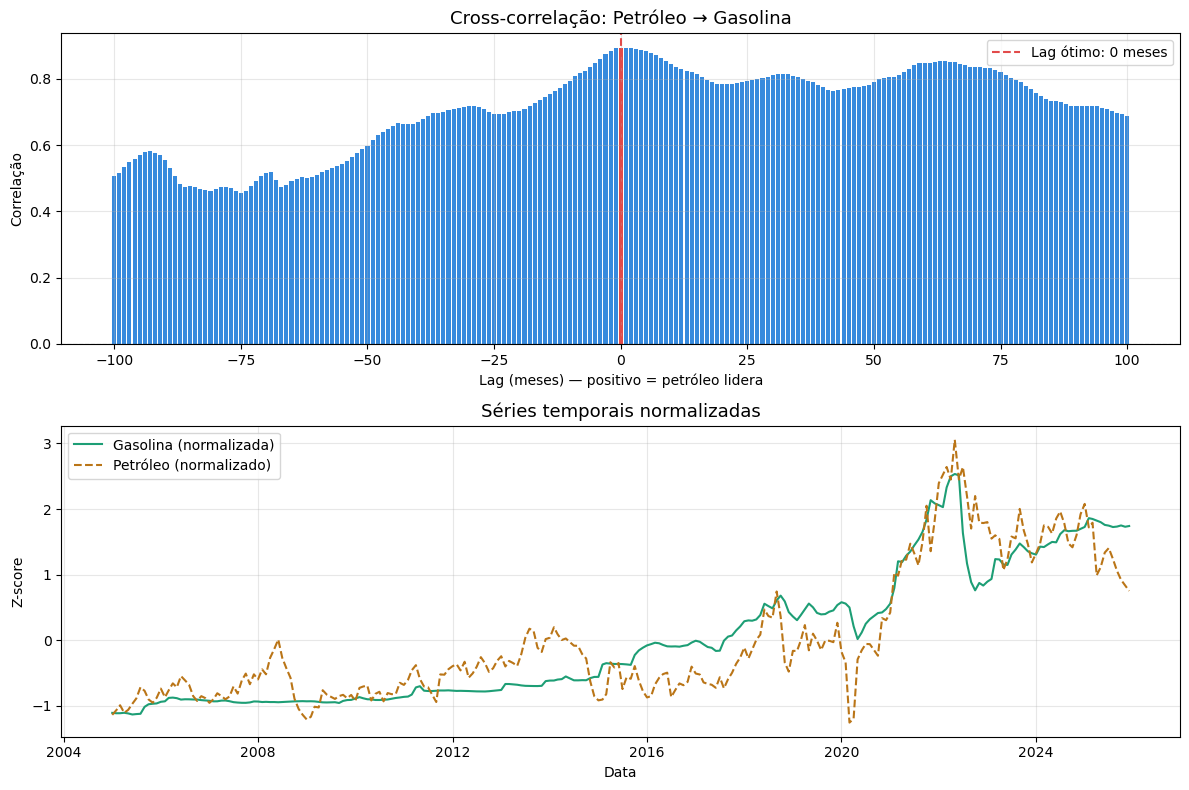

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

#  Gráfico 1: Correlação cruzada
cores = ['#E24B4A' if l == lag_otimo else '#378ADD' for l in lags]
axes[0].bar(lags, corrs, color=cores, width=0.8)
axes[0].axvline(lag_otimo, color='#E24B4A', linewidth=1.5, linestyle='--', label=f'Lag ótimo: {lag_otimo} meses')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_title('Cross-correlação: Petróleo → Gasolina', fontsize=13)
axes[0].set_xlabel('Lag (meses) — positivo = petróleo lidera')
axes[0].set_ylabel('Correlação')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Séries normalizadas sobrepostas 
datas = df_lag.index.to_timestamp()
axes[1].plot(datas, znorm(df_lag['gasolina']), color='#1D9E75', linewidth=1.5, label='Gasolina (normalizada)')
axes[1].plot(datas, znorm(df_lag['petroleo']), color='#BA7517', linewidth=1.5, linestyle='--', label='Petróleo (normalizado)')
axes[1].set_title('Séries temporais normalizadas', fontsize=13)
axes[1].set_xlabel('Data')
axes[1].set_ylabel('Z-score')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('lag_gasolina_petroleo.png', dpi=150, bbox_inches='tight')
plt.show()

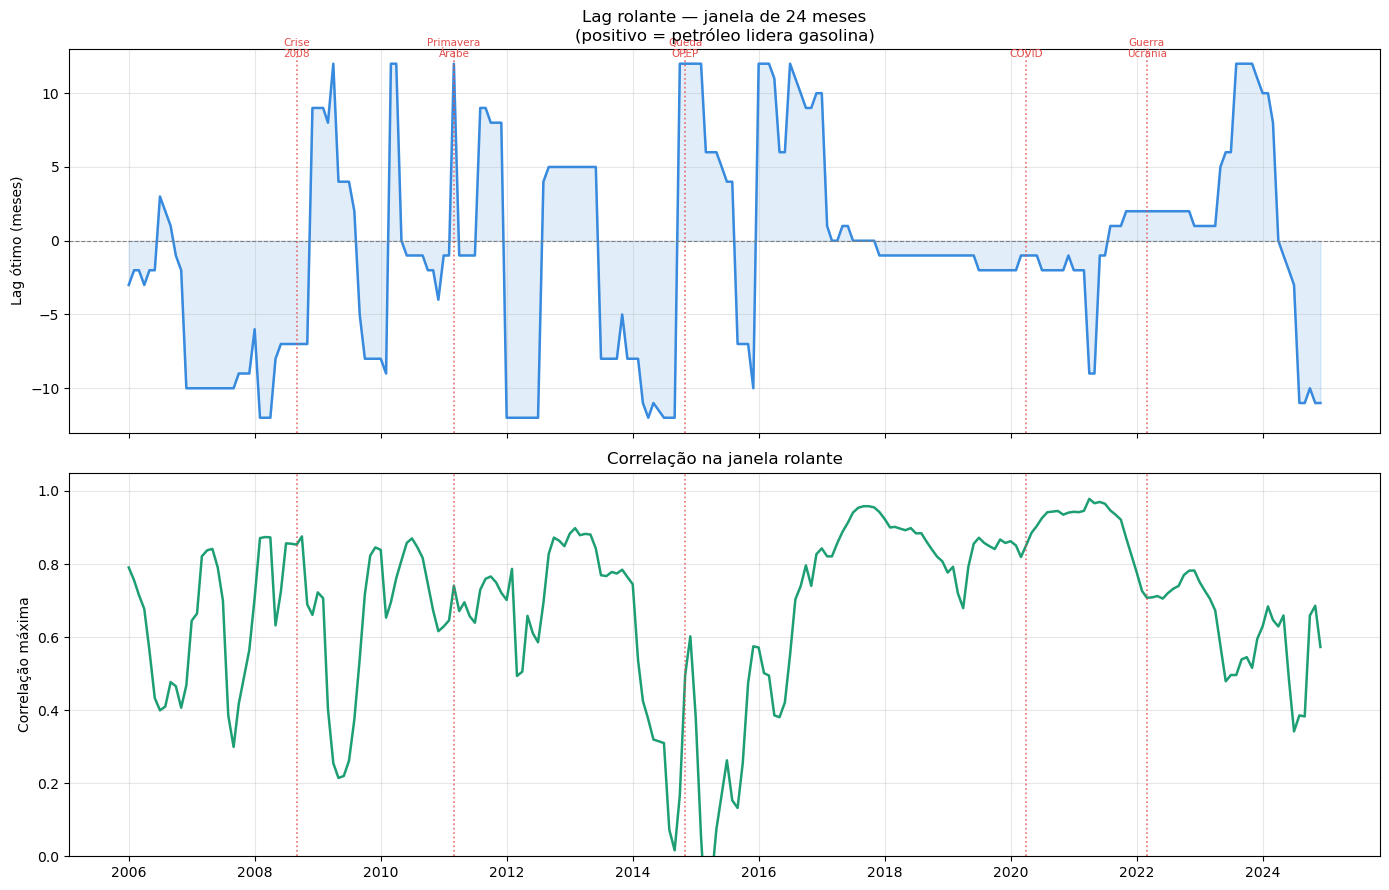

In [34]:
#Lag entre uma janela menor
#Vamos analisar o lag agora em espaços de tempo específicos
janela = 24  # meses por janela
step = 1     # avança 1 mês por vez
max_lag_roll = 12  # testa lags de -12 a +12 meses

datas_roll, lags_roll, corrs_roll = [], [], []

gn_full = znorm(df_lag['gasolina']).values
pn_full = znorm(df_lag['petroleo']).values
idx_datas = df_lag.index.to_timestamp()

for i in range(0, len(gn_full) - janela, step):
    g_win = gn_full[i:i + janela]
    p_win = pn_full[i:i + janela]
    
    best_lag, best_corr = 0, -np.inf
    for lag in range(-max_lag_roll, max_lag_roll + 1):
        pairs = [(g_win[j], p_win[j + lag]) for j in range(janela) if 0 <= j + lag < janela]
        if len(pairs) < 10:
            continue
        g_arr, p_arr = zip(*pairs)
        c = np.corrcoef(g_arr, p_arr)[0, 1]
        if c > best_corr:
            best_corr = c
            best_lag = lag
    
    datas_roll.append(idx_datas[i + janela // 2])  # data do meio da janela
    lags_roll.append(best_lag)
    corrs_roll.append(best_corr)

#  Choques históricos para marcar 
choques = {
    '2008-09': 'Crise\n2008',
    '2011-03': 'Primavera\nÁrabe',
    '2014-11': 'Queda\nOPEP',
    '2020-04': 'COVID',
    '2022-03': 'Guerra\nUcrânia',
}

# --- Plot ---
fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# Lag rolante
axes[0].plot(datas_roll, lags_roll, color='#378ADD', linewidth=1.8)
axes[0].fill_between(datas_roll, lags_roll, 0, alpha=0.15, color='#378ADD')
axes[0].axhline(0, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_ylabel('Lag ótimo (meses)')
axes[0].set_title(f'Lag rolante — janela de {janela} meses\n(positivo = petróleo lidera gasolina)', fontsize=12)
axes[0].set_ylim(-max_lag_roll - 1, max_lag_roll + 1)
axes[0].grid(True, alpha=0.3)

# Correlação rolante
axes[1].plot(datas_roll, corrs_roll, color='#1D9E75', linewidth=1.8)
axes[1].set_ylabel('Correlação máxima')
axes[1].set_title('Correlação na janela rolante', fontsize=12)
axes[1].set_ylim(0, 1.05)
axes[1].grid(True, alpha=0.3)

# Marcarmos os  choques nos dois subplots
for data_str, label in choques.items():
    d = pd.Timestamp(data_str)
    for ax in axes:
        ax.axvline(d, color='#E24B4A', linewidth=1.2, linestyle=':', alpha=0.8)
    axes[0].text(d, max_lag_roll + 0.3, label, fontsize=7.5,
                 ha='center', color='#E24B4A', va='bottom')

plt.tight_layout()
plt.savefig('lag_rolante_choques.png', dpi=150, bbox_inches='tight')
plt.show()